Here, I do a simple experiment to see how uncertainty (without bias) in the matrix elements relates to uncertainty and bias in the ground state estimator.

The conclusion of this experiment is that there is bias in the estimator. 

In [55]:
import numpy as np
from numpy.random import uniform, normal
import matplotlib.pyplot as plt

In [ ]:
# initialize fixed symmetric matrix and calculate its ground state energy

dim = 5
X   = uniform(-1, 1, [dim,dim])
X   = X + X.T
Egs = min(np.linalg.eigh(X)[0])

# now, estimate Egs by sampling the ground state energy of X + (random error) a bunch of times, and see what it converges to

Nsamples                   = 50000000
samples                    = np.zeros(Nsamples)
diag_standard_deviation    = 0.001
offdiag_standard_deviation = 0.0001

for i in range(Nsamples):
    error_matrix = np.zeros([dim,dim])
    
    for alpha in range(dim):
        for beta in range(alpha,dim):
            
            if alpha == beta:
                random_value             = normal(loc=0, scale=diag_standard_deviation)
                error_matrix[alpha,beta] = random_value
            
            else:
                random_value             = normal(loc=0, scale=offdiag_standard_deviation)
                error_matrix[alpha,beta] = random_value
                error_matrix[beta,alpha] = random_value

    Egs_sampled = min(np.linalg.eigh(X + error_matrix)[0])
    samples[i]  = Egs_sampled

    if i % 1000 == 0:
        print(i, end='\r')

estimator_values = np.cumsum(samples) / np.arange(1, Nsamples + 1)
# assert np.linalg.norm(estimator_values - np.array([np.mean(samples[:i+1]) for i in range(len(samples))])) < 1e-10

(-1e-06, 1e-06)

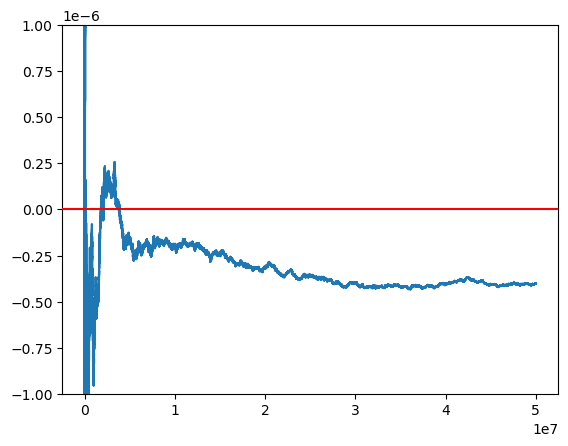

In [54]:
plt.figure()
plt.plot(estimator_values - Egs)
plt.axhline(y=0, color='red', zorder=10)
plt.ylim(-0.000001, 0.000001)

In [57]:
# initialize fixed symmetric matrix and calculate its ground state energy

dim = 10
X   = uniform(-1, 1, [dim,dim])
X   = X + X.T
Egs = min(np.linalg.eigh(X)[0])

# now, estimate Egs by sampling the ground state energy of X + (random error) a bunch of times, and see what it converges to

Nsamples                   = 50000000
samples                    = np.zeros(Nsamples)
diag_standard_deviation    = 0.001
offdiag_standard_deviation = 0.0001

for i in range(Nsamples):
    error_matrix = np.zeros([dim,dim])
    
    for alpha in range(dim):
        for beta in range(alpha,dim):
            
            if alpha == beta:
                random_value             = normal(loc=0, scale=diag_standard_deviation)
                error_matrix[alpha,beta] = random_value
            
            else:
                random_value             = normal(loc=0, scale=offdiag_standard_deviation)
                error_matrix[alpha,beta] = random_value
                error_matrix[beta,alpha] = random_value

    Egs_sampled = min(np.linalg.eigh(X + error_matrix)[0])
    samples[i]  = Egs_sampled

    if i % 1000 == 0:
        print(i, end='\r')

estimator_values = np.cumsum(samples) / np.arange(1, Nsamples + 1)
# assert np.linalg.norm(estimator_values - np.array([np.mean(samples[:i+1]) for i in range(len(samples))])) < 1e-10

(-1e-06, 1e-06)

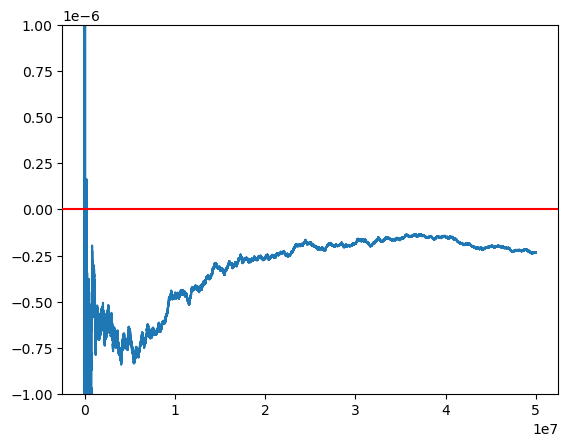

In [58]:
plt.figure()
plt.plot(estimator_values - Egs)
plt.axhline(y=0, color='red', zorder=10)
plt.ylim(-0.000001, 0.000001)

In [67]:
# initialize fixed symmetric matrix and calculate its ground state energy

dim = 2
X   = uniform(-1, 1, [dim,dim])
X   = X + X.T
Egs = min(np.linalg.eigh(X)[0])

# now, estimate Egs by sampling the ground state energy of X + (random error) a bunch of times, and see what it converges to

Nsamples                   = 100000000
samples                    = np.zeros(Nsamples)
diag_standard_deviation    = 0.01
offdiag_standard_deviation = 0.001

for i in range(Nsamples):
    error_matrix = np.zeros([dim,dim])
    
    for alpha in range(dim):
        for beta in range(alpha,dim):
            
            if alpha == beta:
                random_value             = normal(loc=0, scale=diag_standard_deviation)
                error_matrix[alpha,beta] = random_value
            
            else:
                random_value             = normal(loc=0, scale=offdiag_standard_deviation)
                error_matrix[alpha,beta] = random_value
                error_matrix[beta,alpha] = random_value

    Egs_sampled = min(np.linalg.eigh(X + error_matrix)[0])
    samples[i]  = Egs_sampled

    if i % 1000 == 0:
        print(i, end='\r')

estimator_values = np.cumsum(samples) / np.arange(1, Nsamples + 1)
# assert np.linalg.norm(estimator_values - np.array([np.mean(samples[:i+1]) for i in range(len(samples))])) < 1e-10

(-0.0001, 0.0001)

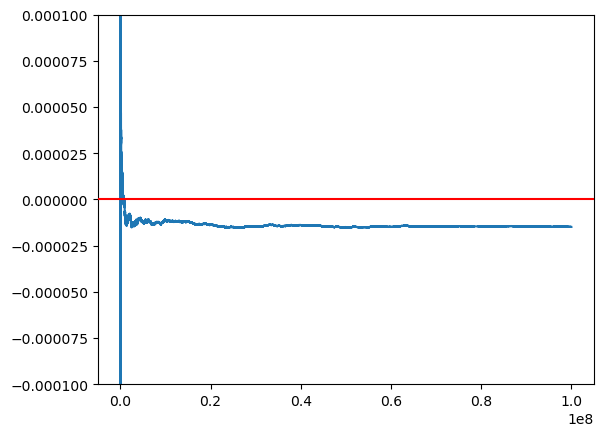

In [69]:
plt.figure()
plt.plot(estimator_values - Egs)
plt.axhline(y=0, color='red', zorder=10)
plt.ylim(-0.0001, 0.0001)